**Kmeans clustering**

Dataset: Mall customers.csv

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

%matplotlib inline

**Load the dataset**

In [ ]:
path = "/content/drive/MyDrive/Data Science Datasets/Mall_Customers.csv"

In [ ]:
mall_cust=pd.read_csv(path)

**Display first five records**

In [ ]:
mall_cust.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Display last five records**

In [ ]:
mall_cust.tail(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


**check the datatypes**

In [ ]:
mall_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


**shape of the data**

In [ ]:
mall_cust.shape

(200, 5)

**check missing values**

In [ ]:
mall_cust.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


**Observations**



1.   The dataset was imported and loaded correctly.
2.   The first and last five records were displayed successfully.


1.   The dataset has 4 columns of integer type and 1 column of object datatype.
2.   The dataset has no missing values.


1.   The dataset has 200 records and 5 columns









**check statistical summaries**

In [ ]:
mall_cust.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.88,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.97,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.26,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.82,1.0,34.75,50.0,73.00,99.0


**Observations**



1.   The mean age is 38.85 and the average age is 36.0 , there is variability and is a right skew thus not normal , min age is 18 and max age is 70.
2.   The mean annual income is 60.56 and average annual income is 61.5, there is no variabilty and distribution is normal , min annual income is 15.0 and max annual income is 137.0$.


1.   The mean spending score is 50.20 and average spending score is 50.0 , there is no variability thus a normal distribution, the min spending score is 1.0 and max spending score is 99.0 .






**Univariate analysis**

**age distribution**

Text(0.5, 1.0, 'Age Distribution')

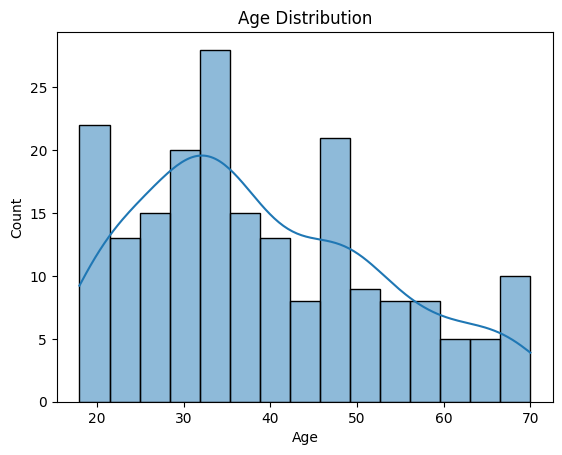

In [ ]:
sns.histplot(data=mall_cust,x="Age", kde= True, bins=15 )
plt.title("Age Distribution")


**Observations**
- Age Range: The data covers customers ranging from approximately 18 to 70 years old.

- Primary Peak : The highest concentration of customers falls within the 30–35 age group, with a count of nearly 30 individuals.

- Secondary Peaks: There are notable surges in the 18–22 range and again in the 45–50 range.

- Distribution Shape: The chart shows a right-skewed distribution (positively skewed). While there is a solid presence of older customers, the density tapers off as age increases toward 70.

**Interpretation**
1. Target Population
The mall’s "sweet spot" is the young professional and early-parenting demographic (ages 25–40). These individuals often have increasing disposable income and diverse shopping needs, ranging from fashion to household goods.

2. The young population surge
The significant spike at the far left (ages 18–22) suggests the mall is a popular destination for students or Gen Z shoppers. This could be due to affordable fast-fashion retailers, entertainment zones, or food courts that appeal to a younger crowd.

3. The Middle-Age Retention
The secondary bump around age 45–50 suggests a loyal segment of middle-aged shoppers. These customers might be more interested in high-end brands, department stores, or home improvement outlets.

4. Senior Engagement
The dip in customers over age 60 (with a small uptick at 70) indicates that the mall may not be the primary shopping destination for seniors, or perhaps the current store mix doesn't cater as heavily to their specific interests.

Annual income distribution

Text(0.5, 1.0, 'Annual Income Distribution')

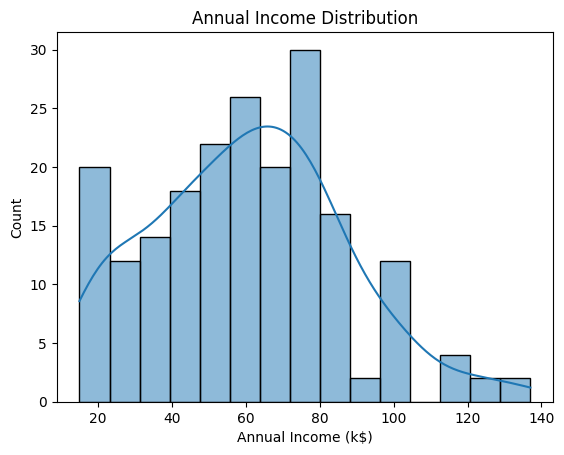

In [ ]:
sns.histplot(data=mall_cust,x="Annual Income (k$)", kde= True, bins=15 )
plt.title("Annual Income Distribution")

**Observation**
1. Income Range: Most customers earn between $15k and $137k annually.

2. The "Middle Class" Peak: There is a significant concentration of customers in the 50k–80k range, with the absolute peak occurring between 70k and 80k.

3. Low-Income Segment: There is a secondary spike at the low end, around 15k–25k.

4. High-Income Tail: The distribution tapers off sharply after 90k, with very few customers earning above 110k.

5. Distribution Type: The data follows a roughly Normal Distribution but is slightly right-skewed, meaning the majority are middle-income earners with a few "outlier" high earners.

**Interpretation**
- Mass Market Appeal: The mall primarily caters to the middle-income bracket. The high volume of shoppers in the 60k–80k range suggests that mid-tier retail brands and standard department stores are likely the most successful.

- Budget Sensitivity: The spike in the 20k range indicates a significant segment of budget-conscious shoppers (possibly the students/younger demographic noted in the age chart). Value stores and discount outlets are necessary to keep this group engaged.

- Limited Luxury Presence: Because the count of customers earning over $100k is quite low, the mall may not be the ideal location for ultra-high-end luxury boutiques. There isn't a large enough "top-tier" audience to sustain many premium-only stores.

- Strategic Pricing: Marketing efforts and pricing strategies should focus on "attainable luxury" or "middle-market" value, as this aligns with where the bulk of the customers' spending power lies (50k–80k).

Spending score distribution

Text(0.5, 1.0, 'Spending Score Distribution')

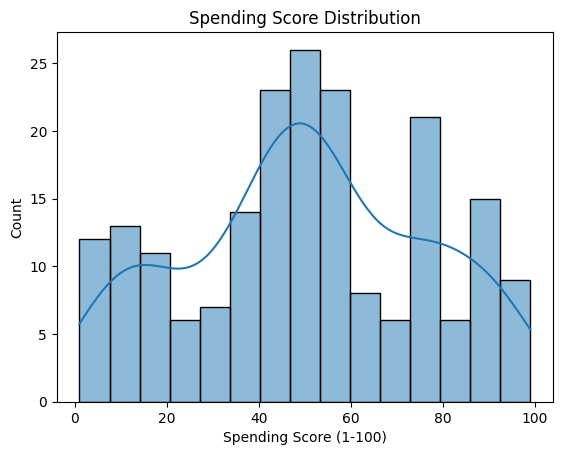

In [ ]:
sns.histplot(data=mall_cust,x="Spending Score (1-100)", kde= True, bins=15)
plt.title("Spending Score Distribution")

**Observation**
1. The "Average" Majority: The largest cluster of customers sits right in the middle, with a peak spending score between 40 and 60.

2. Beyond the central peak, there are two other distinct "bumps":

- A low-spending group with scores between 1 and 20.

- A high-spending group with scores between 70 and 80.



**Interpretation**
1. The  Scores 1–30: This group visits the mall but spends very little. They might be using the mall for social reasons, exercise (mall walking), or are highly disciplined budgeters who only buy essentials.

2. The  Scores 40–60: These are your reliable, average shoppers. They likely represent the middle-income earners we saw in the previous graph—people who shop regularly but moderately.

3. The Scores 70–100: These are the mall’s most valuable customers.  This group likely includes "impulse buyers" or those who prioritize lifestyle and fashion trends.

4. Marketing Strategy:
- For the 40–60 group: Use loyalty programs to keep them coming back.

- For the 70+ group: Use exclusive previews or VIP events to maximize their high propensity to spend.

- For the < 20 group: Use heavy discounts or "loss-leader" deals to entice them to finally make a purchase.

Gender distribution

<Axes: xlabel='Gender', ylabel='count'>

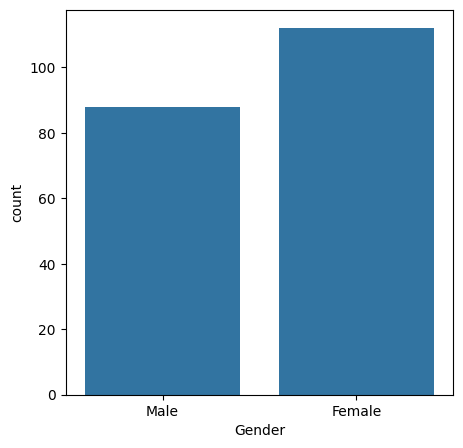

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(data=mall_cust,x="Gender")

**Observation**
- Females represent the majority of the sampled customer base with a count of 100+ and males with a count of 80+

**Interpretation**
- Primary Consumer Base: The data suggests that the mall is a more popular destination for women. This could indicate that the current store directory—likely featuring more fashion, beauty, or lifestyle brands—aligns better with female shopping preferences.

- Marketing Focus: From a business perspective, marketing campaigns are likely to yield a higher return on investment if they continue to target female shoppers, as they already form the bulk of the foot traffic.

- Growth Opportunity: The lower male count represents an untapped market. The mall could consider introducing more "male-oriented" retail options—such as electronics, specialized sporting goods, or grooming services—to balance the demographic and increase overall revenue.

Bivariate analysis

<Axes: xlabel='Gender', ylabel='Annual Income (k$)'>

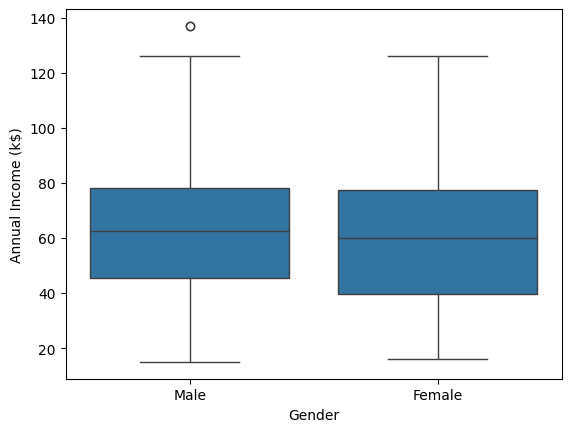

In [ ]:
sns.boxplot(data=mall_cust,x="Gender",y="Annual Income (k$)")


**Observation**
1.  Median Income: The median income is slightly higher for Males  compared to Females.

2. Income Range (IQR): The "boxes"  are very similar in size, though the female box starts slightly lower  compared to the male box.

3. Outlier: There is one high-earning male "outlier" reaching nearly 140k, whereas the female income distribution is more contained.
4. Overall Spread: Both genders have a similar overall range.

**Interpretation**
- Equal Purchasing Power: Even though women visit the mall more often, they do not necessarily have more money than the men. Both groups have the same financial capacity to spend.

- Middle-Class Focus: The mall’s core audience, regardless of gender, is firmly middle-income.

- Marketing Insight: Pricing strategies don't need to be gender-specific. Both men and women at this mall are looking for products in the same price bracket.

<Axes: xlabel='Gender', ylabel='Spending Score (1-100)'>

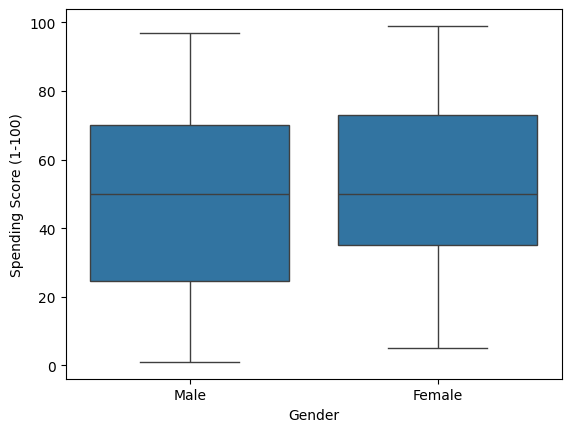

In [ ]:
sns.boxplot(data=mall_cust,x="Gender",y="Spending Score (1-100)")

Observation
- Identical Median: The median spending score for both Males and Females is exactly the same, sitting at 50.

- Interquartile Range (IQR): The "box" for female shoppers is slightly higher and more compact than the male box.

- Consistency: Females show a slightly higher "floor" for their typical spending (the bottom of the box is higher), suggesting a more consistent group of moderate-to-high spenders.

- overall: Both genders span the full range of scores, from nearly 0 to 100, indicating that "power shoppers" and "window shoppers" exist in both groups.

**Interpretation**
- Equal Spending : Despite the common stereotype that women spend more, this data shows that on an individual basis, men and women spend almost identically. If a man walks into the mall, he is statistically just as likely to have a spending score of 50 as a woman is.

- The "Volume" Factor: When we combine this with the earlier bar chart (which showed significantly more female shoppers), we can conclude that women generate more total revenue for the mall simply because there are more of them, not because they spend more per person.

- Reliable Females vs. Variable Males: The slightly higher and tighter box for females suggests they are a more "reliable" demographic. Men's spending scores are a bit more spread out toward the lower end, indicating a larger percentage of men who visit but don't buy anything.

- Marketing insight : Since the median spending and income are nearly identical across genders, the mall’s pricing and promotional tiers can remain consistent for both. The real challenge for the mall is not how to make men spend more, but how to increase the volume of men.

Annual income and spending score  in comparison to age

Text(0, 0.5, 'Annual Income')

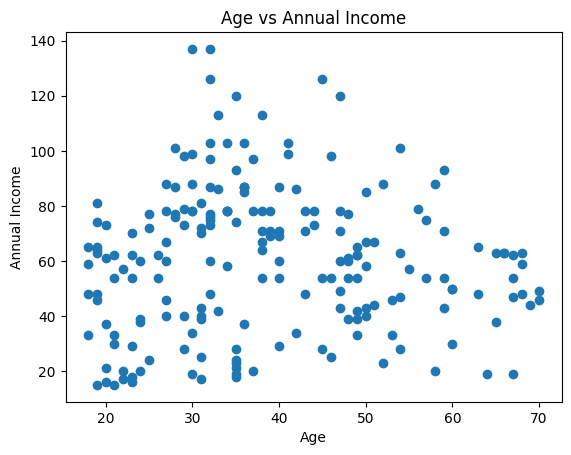

In [ ]:
plt.scatter(data=mall_cust,x="Age",y="Annual Income (k$)")
plt.title("Age vs Annual Income")
plt.xlabel("Age")
plt.ylabel("Annual Income")

**Observation**
- Weak Correlation: There is no strong linear relationship between age and income. High and low earners are scattered across almost all age groups.

- Peak Earning Cluster: The highest earners (those making $100k–$140k) are predominantly concentrated in the 30–50 age range.

-  Customers over the age of 60 show a much tighter income distribution, generally earning between 40k and 80k. You don't see the extreme "wealth spikes" or "low-income dips" in this older group.

- Youthful Variance: Younger shoppers (under 25) have a wide spread, with many earning very little less than 20k but a surprising few already hitting the 60k–80k mark.

**Interpretation**
- Middle-Age Dominance: The "Prime Spender" identified in previous charts (Age 30–35) is confirmed here to be among the highest earners. This group has both the means (high income) and the motivation (as seen in the Age chart) to shop at the mall.

- Retail Strategy: Since the highest income spikes happen in the 30s and 40s, luxury or premium retailers should focus their marketing on this specific "middle-age" window rather than targeting older retirees.

- The tight clustering of income for customers over 60 suggests a demographic on fixed incomes (pensions or social security). They are a stable but less "high-growth" segment for the mall.

- We can see a trajectory : income starts low and varied in the 20s, peaks and expands in the 30s-40s, and then stabilizes and narrows as customers move into their 60s.

Text(0, 0.5, 'Spending Score')

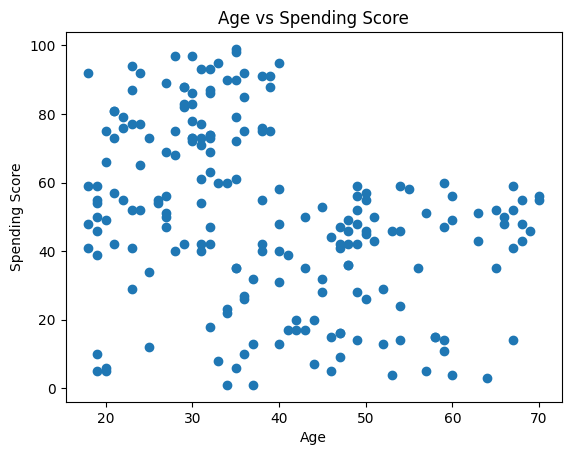

In [ ]:
plt.scatter(data=mall_cust,x="Age",y="Spending Score (1-100)")
plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

**Observations**
1. High spending scores (above 60) are almost exclusively concentrated in customers under age 40.

2.  Customers over age 40 show a very disciplined spending pattern, with scores almost entirely capped at 60.

3. High Variance in Youth: Younger shoppers (18–35) show the widest range, including both the highest spenders and very low spenders.

**Interpretations**
1. Youthful Impulse: Younger customers are more likely to be "High Spenders." This demographic is likely more susceptible to trends, fashion, and impulse purchases.

2. Mature Discipline: Older customers (40–70) appear to be more "mission-driven" or budget-conscious. While they may have more income (as seen in the income vs. age chart), they spend more conservatively within the mall environment.

3. Market Segmentation: If the mall wants to increase revenue quickly, they should target marketing toward the sub-40 demographic, as they have the highest propensity to spend aggressively.

Annual income in comparison to spending score

Text(0, 0.5, 'Spending Score')

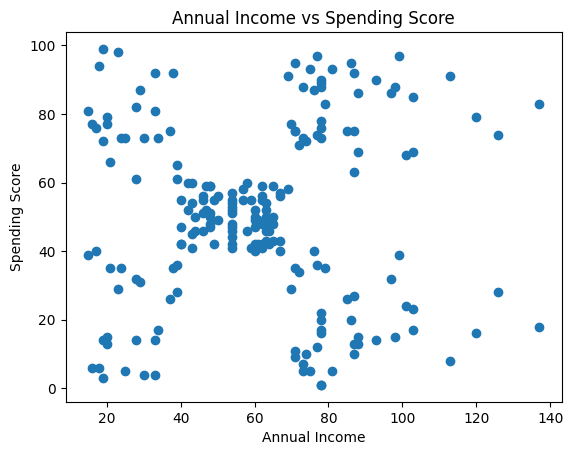

In [ ]:
plt.scatter(data=mall_cust,x="Annual Income (k$)",y="Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

**Observation**
- The plot clearly clusters the customers into five distinct segments:

1. Low Income, Low Spending (Bottom-Left): Shoppers who likely visit for essentials or social reasons but have limited discretionary budget.

2. Low Income, High Spending (Top-Left): Often referred to as the "Impulse" or "Trend-driven" group—likely younger shoppers who prioritize fashion over savings.

3. Middle Income, Average Spending (Center):  This is the largest group, representing stable, consistent revenue for the mall.

4. High Income, Low Spending (Bottom-Right): These individuals have high earning power but are very selective or conservative with their mall purchases.

5. High Income, High Spending (Top-Right):  These are the most valuable customers who have both the money and the willingness to spend it.

**Intrepretation**
1. The mall should maintain its core retail mix to keep the massive central cluster  satisfied.

2. The high-income, high-spending group is relatively small but high-impact. Premium loyalty programs or exclusive concierge services should target this specific quadrant.



Multivariate analysis

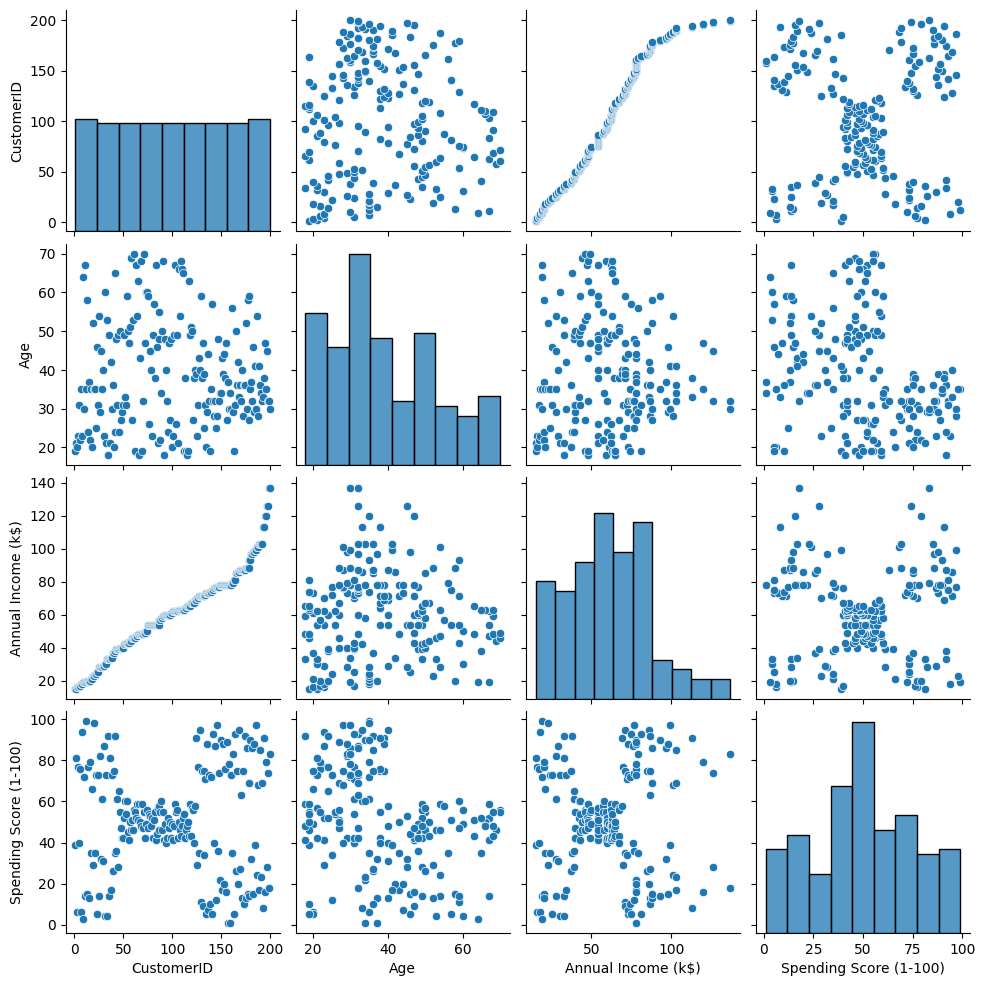

In [ ]:
sns.pairplot(mall_cust)

**Drop unnecessary columns**

In [ ]:
mall_cust_copy=mall_cust.drop(["CustomerID","Gender","Age"],axis=1)

In [ ]:
mall_cust_copy.head(5)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


**Scaling of data**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler= StandardScaler()
mall_cust_df=scaler.fit_transform(mall_cust_copy)

In [ ]:
mall_cust_df

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
wss=[]

In [ ]:
for i in range(1,11):
  k_means=KMeans(n_clusters=i)
  k_means.fit(mall_cust_df)
  wss.append(k_means.inertia_)

In [ ]:
wss

[399.99999999999994,
 269.69101219276405,
 157.70400815035939,
 109.22822707921345,
 98.41025672831277,
 89.95282510128644,
 52.357580209445224,
 46.0735938245881,
 38.99960820083663,
 29.831848847621593]

**Elbow method**

Text(0.5, 1.0, 'Elbow Method')

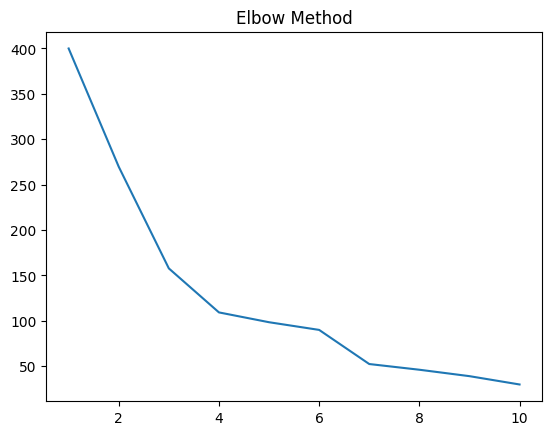

In [ ]:
plt.plot(range(1,11),wss)
plt.title("Elbow Method")

**Computing silhouette scores**

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
sil_scores = []

In [ ]:
for i in range(2,11):
  k_means=KMeans(n_clusters=i, random_state=42)
  k_means.fit(mall_cust_df)
  sil_scores.append(silhouette_score(mall_cust_df,k_means.labels_))

**sil_score plot**

Text(0.5, 1.0, 'Silhouette Score')

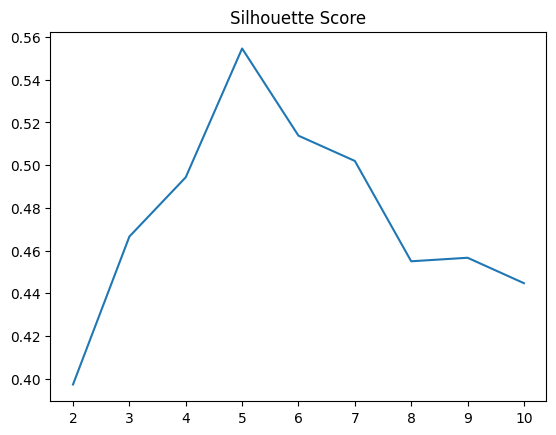

In [ ]:
plt.plot(range(2,11),sil_scores)
plt.title("Silhouette Score")

In [ ]:
k_means=KMeans(n_clusters=5,random_state=42)
k_means.fit(mall_cust_df)
labels = k_means.labels_

In [ ]:
mall_cust["Kmeans_clusters"] = labels

In [ ]:
mall_cust.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Kmeans_clusters
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [ ]:
mall_cust.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Kmeans_clusters'],
      dtype='object')

In [ ]:
mall_customers = mall_cust[['Annual Income (k$)','Spending Score (1-100)','Kmeans_clusters']]

In [ ]:
from sklearn.metrics import silhouette_score, silhouette_samples

# 1. Get the average score for the whole clustering
# 'X' is your data (features), 'labels' are your cluster assignments
avg_score = silhouette_score(mall_cust_df, labels)
print(f"Overall Silhouette Score: {avg_score}")

# 2. Add individual scores to your DataFrame
# This creates the 'sil_score' column you are looking for
mall_cust['sil_score'] = silhouette_samples(mall_cust_df, labels)

Overall Silhouette Score: 0.5546571631111091


In [ ]:
print(mall_cust[['Age', 'Kmeans_clusters']].head())

   Age  Kmeans_clusters
0   19                2
1   21                2
2   20                3
3   23                2
4   31                2


**display cluster 3 members**

In [ ]:
cluster_3_members=mall_cust[mall_cust['Kmeans_clusters'] == 3]
print(f"There are {len(cluster_3_members)} people in Cluster 3.")
print(cluster_3_members[['Age','Gender']].head(10))

There are 32 people in Cluster 3.
    Age  Gender
2    20  Female
47   27  Female
48   29  Female
49   31  Female
52   31  Female
58   27  Female
61   19    Male
65   18    Male
68   19    Male
75   26    Male


In [ ]:

cluster_2_members = mall_cust[mall_cust['Kmeans_clusters'] == 2]

print(f"There are {len(cluster_2_members)} people in Cluster 2.")
print(cluster_2_members[['Age','Gender']].head(10))

There are 25 people in Cluster 2.
    Age  Gender
0    19    Male
1    21    Male
3    23  Female
4    31  Female
5    22  Female
7    23  Female
9    30  Female
11   35  Female
13   24  Female
15   22    Male
